# UAS Kecerdasan Buatan
## Prediksi Kelulusan Siswa Menggunakan Machine Learning
**Nama:** Mahasiswa  
**Dataset:** Student Performance Dataset (Kaggle)  
**Algoritma:** Decision Tree, KNN, SVM, Naive Bayes

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Dataset

In [ ]:
df = pd.read_csv('data/dataset/student-performance.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,M,20,U,GT3,T,0,4,other,at_home,...,2,3,2,5,4,5,27,9,18,13
1,MS,M,19,U,LE3,T,2,4,teacher,teacher,...,1,2,2,5,1,4,1,16,3,12
2,GP,M,18,U,GT3,T,0,1,other,teacher,...,3,3,1,1,4,5,25,8,8,5
3,GP,M,15,U,LE3,A,3,3,teacher,at_home,...,5,2,5,3,3,5,15,11,15,13
4,GP,F,21,R,LE3,T,4,3,at_home,services,...,3,5,3,3,2,2,20,9,13,11


## 2. Data Understanding

In [49]:
print("Statistik Deskriptif:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum().sum(), "missing values")

Statistik Deskriptif:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    17.939241    2.091139    2.010127    2.569620    2.559494    0.478481   
std      1.999075    1.427360    1.386995    1.104715    1.132528    0.849854   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    1.000000    1.000000    2.000000    2.000000    0.000000   
50%     18.000000    2.000000    2.000000    3.000000    3.000000    0.000000   
75%     20.000000    3.000000    3.000000    4.000000    4.000000    1.000000   
max     21.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     2.916456    2.881013    2.964557    2.982278    3.060759    3.164557   
std  

## 3. Exploratory Data Analysis (EDA)

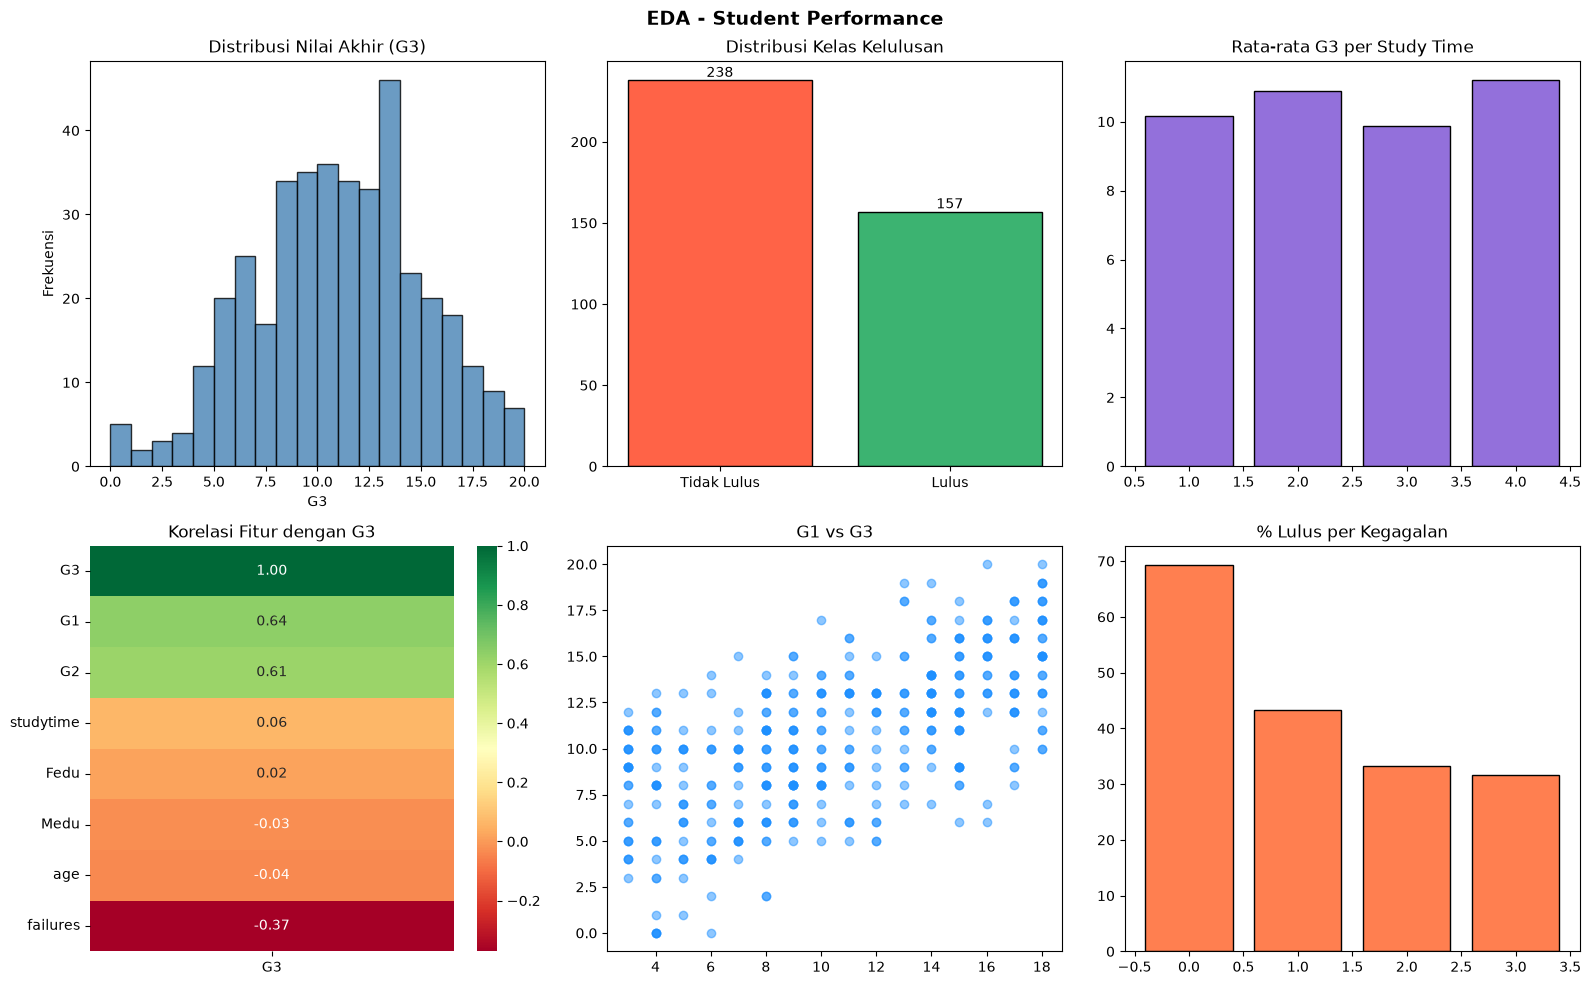

EDA selesai!


In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA - Student Performance', fontsize=14, fontweight='bold')

# Distribusi G3
axes[0,0].hist(df['G3'], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[0,0].set_title('Distribusi Nilai Akhir (G3)')
axes[0,0].set_xlabel('G3'); axes[0,0].set_ylabel('Frekuensi')

# Distribusi kelulusan
df['lulus'] = (df['G3'] >= 10).astype(int)
counts = df['lulus'].value_counts()
axes[0,1].bar(['Tidak Lulus', 'Lulus'], counts.values, color=['tomato','mediumseagreen'], edgecolor='black')
axes[0,1].set_title('Distribusi Kelas Kelulusan')
for i, v in enumerate(counts.values): axes[0,1].text(i, v+2, str(v), ha='center')

# Studytime vs G3
study_g3 = df.groupby('studytime')['G3'].mean()
axes[0,2].bar(study_g3.index, study_g3.values, color='mediumpurple', edgecolor='black')
axes[0,2].set_title('Rata-rata G3 per Study Time')

# Korelasi dengan G3
num_cols = ['age','Medu','Fedu','studytime','failures','G1','G2','G3']
corr = df[num_cols].corr()
sns.heatmap(corr[['G3']].sort_values('G3',ascending=False), ax=axes[1,0],
            annot=True, fmt='.2f', cmap='RdYlGn')
axes[1,0].set_title('Korelasi Fitur dengan G3')

# Scatter G1 vs G3
axes[1,1].scatter(df['G1'], df['G3'], alpha=0.5, color='dodgerblue')
axes[1,1].set_title('G1 vs G3')

# Failures vs kelulusan
fail_lulus = df.groupby('failures')['lulus'].mean() * 100
axes[1,2].bar(fail_lulus.index, fail_lulus.values, color='coral', edgecolor='black')
axes[1,2].set_title('% Lulus per Kegagalan')

plt.tight_layout()
plt.savefig('data/eda_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA selesai!")

## 4. Data Preparation

In [51]:
df_prep = df.copy()

# Label Encoding
cat_cols = ['school','sex','address','famsize','Pstatus','Mjob','Fjob',
            'reason','guardian','schoolsup','famsup','paid','activities',
            'nursery','higher','internet','romantic']
le = LabelEncoder()
for col in cat_cols:
    df_prep[col] = le.fit_transform(df_prep[col])

# Fitur & target
feature_cols = [c for c in df_prep.columns if c not in ['G3', 'lulus']]
X = df_prep[feature_cols]
y = df_prep['lulus']

# Standardisasi & split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Testing set : {X_test.shape}")
print(f"Distribusi kelas: {y.value_counts().to_dict()}")

Training set: (316, 32)
Testing set : (79, 32)
Distribusi kelas: {1: 238, 0: 157}


## 5. Modeling

In [52]:
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'KNN'          : KNeighborsClassifier(n_neighbors=7),
    'SVM'          : SVC(kernel='rbf', C=1.0, random_state=42),
    'Naive Bayes'  : GaussianNB()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall'   : recall_score(y_test, y_pred, zero_division=0),
        'f1'       : f1_score(y_test, y_pred, zero_division=0),
    }
    print(f"[{name}] Acc={results[name]['accuracy']:.3f} | F1={results[name]['f1']:.3f}")

[Decision Tree] Acc=0.810 | F1=0.831
[KNN] Acc=0.759 | F1=0.808
[SVM] Acc=0.797 | F1=0.837
[Naive Bayes] Acc=0.797 | F1=0.830


## 6. Evaluasi - Confusion Matrix

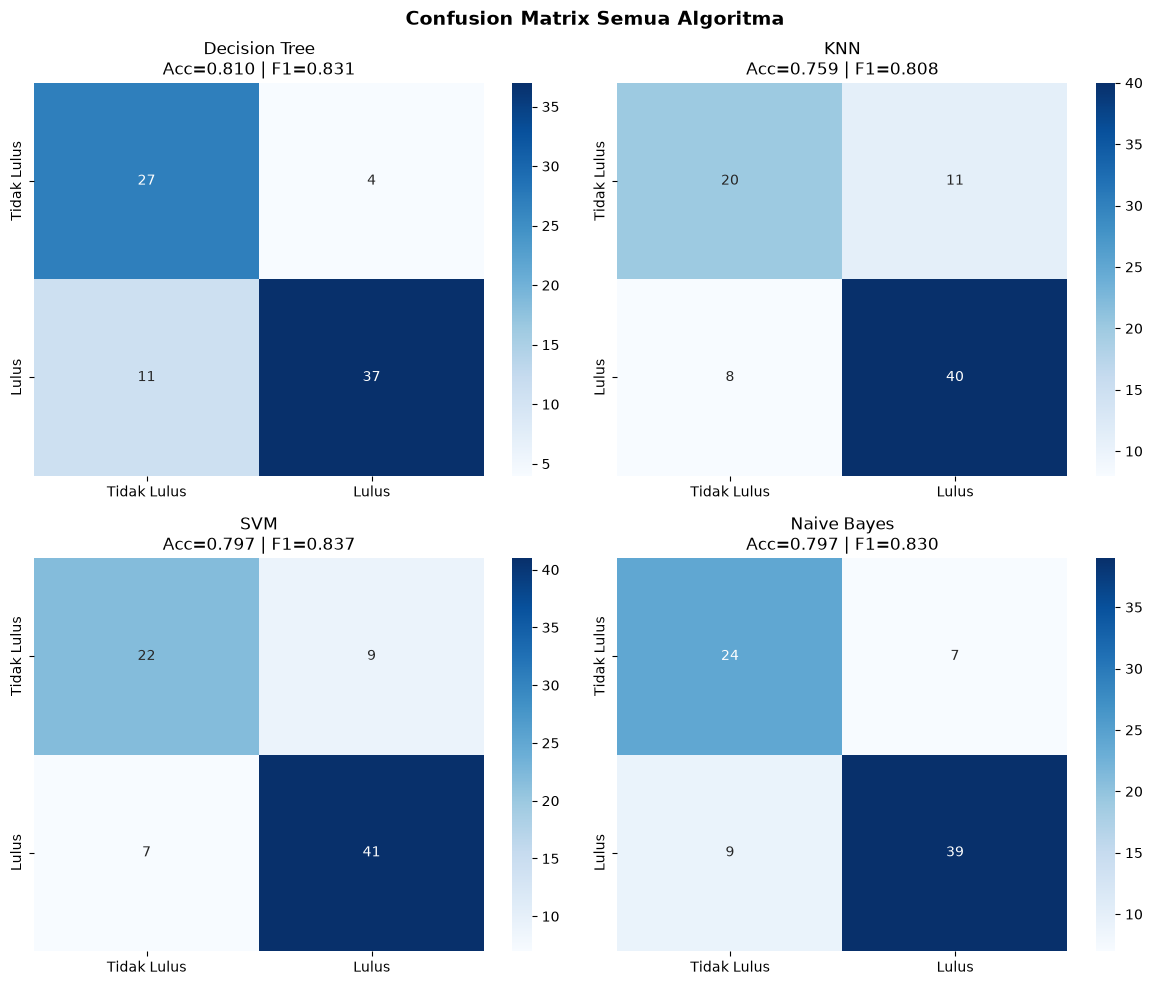

In [53]:
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
fig2.suptitle('Confusion Matrix Semua Algoritma', fontsize=14, fontweight='bold')
axes2_flat = axes2.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes2_flat[idx], cmap='Blues',
                xticklabels=['Tidak Lulus','Lulus'],
                yticklabels=['Tidak Lulus','Lulus'])
    axes2_flat[idx].set_title(f'{name}\nAcc={res["accuracy"]:.3f} | F1={res["f1"]:.3f}')

plt.tight_layout()
plt.savefig('data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Perbandingan Model

    Algoritma  Accuracy  Precision   Recall  F1-Score
          SVM  0.797468   0.820000 0.854167  0.836735
Decision Tree  0.810127   0.902439 0.770833  0.831461
  Naive Bayes  0.797468   0.847826 0.812500  0.829787
          KNN  0.759494   0.784314 0.833333  0.808081

🏆 Model Terbaik: SVM (F1-Score: 0.8367)


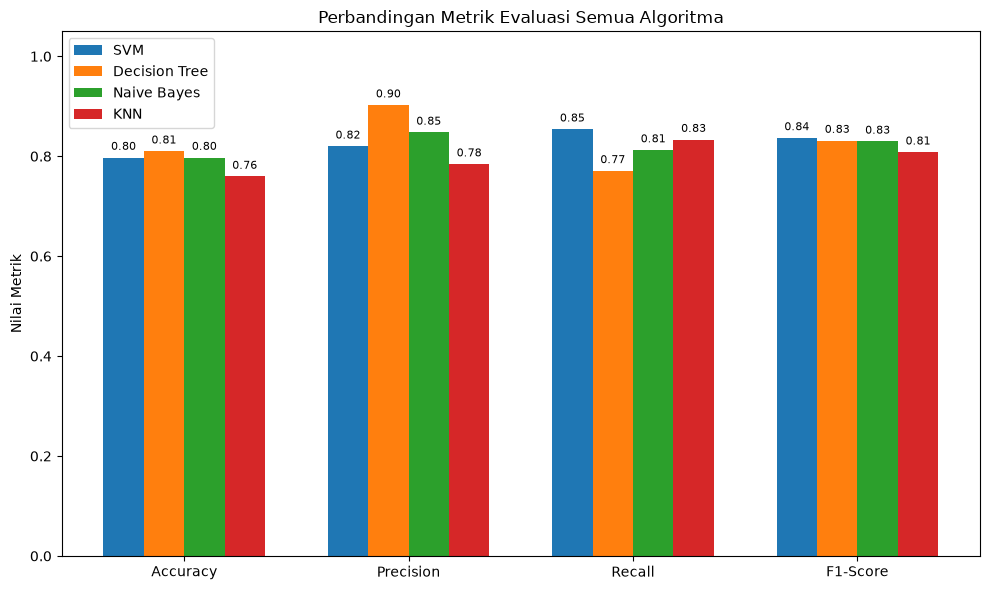

In [56]:
summary = pd.DataFrame([
    {'Algoritma': name, 'Accuracy': r['accuracy'],
     'Precision': r['precision'], 'Recall': r['recall'], 'F1-Score': r['f1'] }
    for name, r in results.items()
])
summary = summary.sort_values('F1-Score', ascending=False)
print(summary.to_string(index=False))

best = summary.iloc[0]
print(f"\n🏆 Model Terbaik: {best['Algoritma']} (F1-Score: {best['F1-Score']:.4f})")

# Plot perbandingan metrik (ditampilkan sebagai output sel)
metrics = ['Accuracy','Precision','Recall','F1-Score']
labels = summary['Algoritma'].tolist()
import numpy as np
x = np.arange(len(metrics))
width = 0.18
fig, ax = plt.subplots(figsize=(10,6))
for i, alg in enumerate(labels):
    scores = summary.loc[summary['Algoritma']==alg, metrics].values.flatten()
    ax.bar(x + i*width, scores, width, label=alg)
    for j, v in enumerate(scores):
        ax.text(x[j] + i*width, v+0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + width*(len(labels)-1)/2)
ax.set_xticklabels(metrics)
ax.set_ylim(0,1.05)
ax.set_ylabel('Nilai Metrik')
ax.set_title('Perbandingan Metrik Evaluasi Semua Algoritma')
ax.legend()
plt.tight_layout()
plt.savefig('data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()